# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [4]:
df= pd.read_csv('Accidents_Clean.csv')

In [5]:
df1 = df.copy(deep = True )

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [9]:
#extract make
make = df1[df1['Airplane'] == True].copy()
make['Make'] = make['Model'].str.split().str[0].str.upper()

In [10]:
#separate into small and large
small_aircraft = make[make['Over5700'] == False].copy()
large_aircraft = make[make['Over5700'] == True].copy()

In [11]:
#filtering makes with N >= 20 accidents
def filter_robust_makes(dataframe, threshold=20):
    make_counts = dataframe['Make'].value_counts()
    robust_makes = make_counts[make_counts >= threshold].index
    return dataframe[dataframe['Make'].isin(robust_makes)]

small_robust = filter_robust_makes(small_aircraft)
large_robust = filter_robust_makes(large_aircraft)

In [12]:
#mean small plane injury
small_injury = small_robust.groupby('Make')['SeriousFatalInjury'].mean().sort_values().head(15)

In [13]:
#mean larg plane injury
large_injury = large_robust.groupby('Make')['SeriousFatalInjury'].mean().sort_values().head(15)

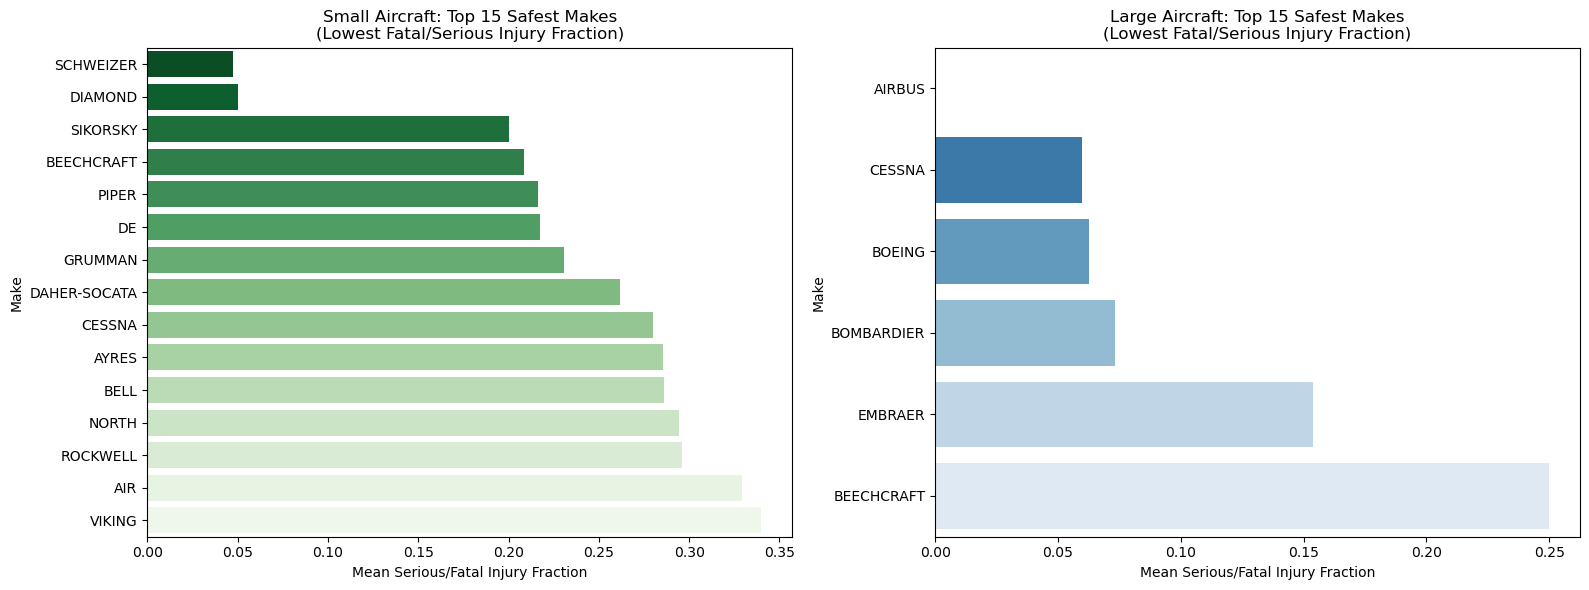

In [18]:
#injury rates side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=small_injury_stats.values, y=small_injury_stats.index, ax=axes[0], palette='Greens_r')
axes[0].set_title('Small Aircraft: Top 15 Safest Makes\n(Lowest Fatal/Serious Injury Fraction)')
axes[0].set_xlabel('Mean Serious/Fatal Injury Fraction')

sns.barplot(x=large_injury_stats.values, y=large_injury_stats.index, ax=axes[1], palette='Blues_r')
axes[1].set_title('Large Aircraft: Top 15 Safest Makes\n(Lowest Fatal/Serious Injury Fraction)')
axes[1].set_xlabel('Mean Serious/Fatal Injury Fraction')
plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [21]:
#top safest planes
top_small = small_injury_stats.head(10).index

df1_small_top = small_robust[small_robust['Make'].isin(top_small)]


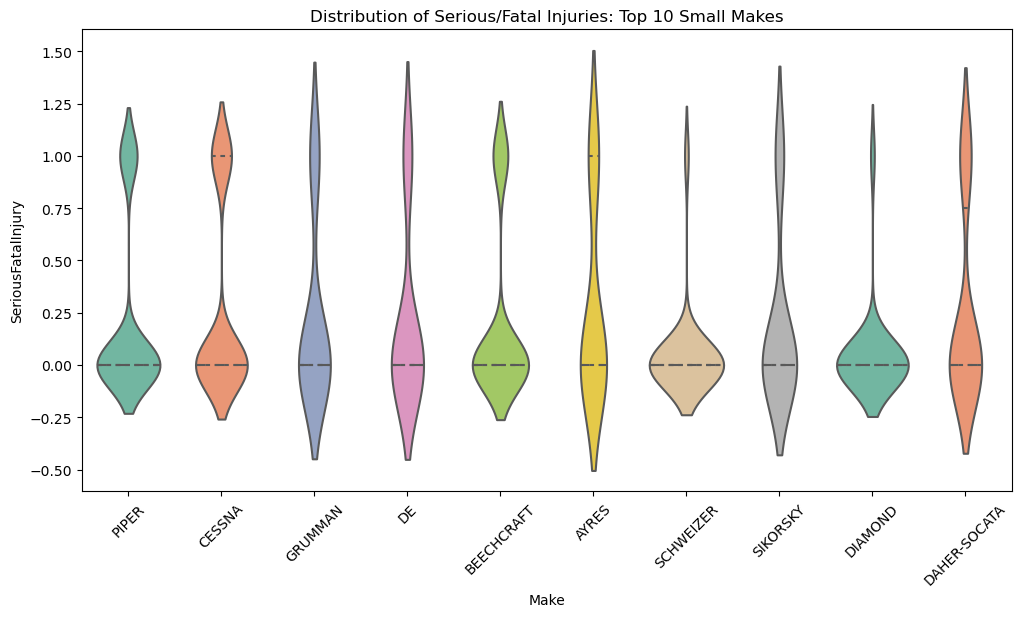

In [22]:
#violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(data=df1_small_top, x='Make', y='SeriousFatalInjury', inner='quartile', palette='Set2')
plt.title('Distribution of Serious/Fatal Injuries: Top 10 Small Makes')
plt.xticks(rotation=45)
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [23]:
top_large = large_injury_stats.head(10).index

df1_large_top = large_robust[large_robust['Make'].isin(top_large)]

C:\Users\juan\AppData\Local\Temp\ipykernel_1328\351910765.py:3: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=df1_large_top, x='Make', y='SeriousFatalInjury', alpha=0.5, jitter=True, palette='Set1')
C:\ProgramData\anaconda4\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda4\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


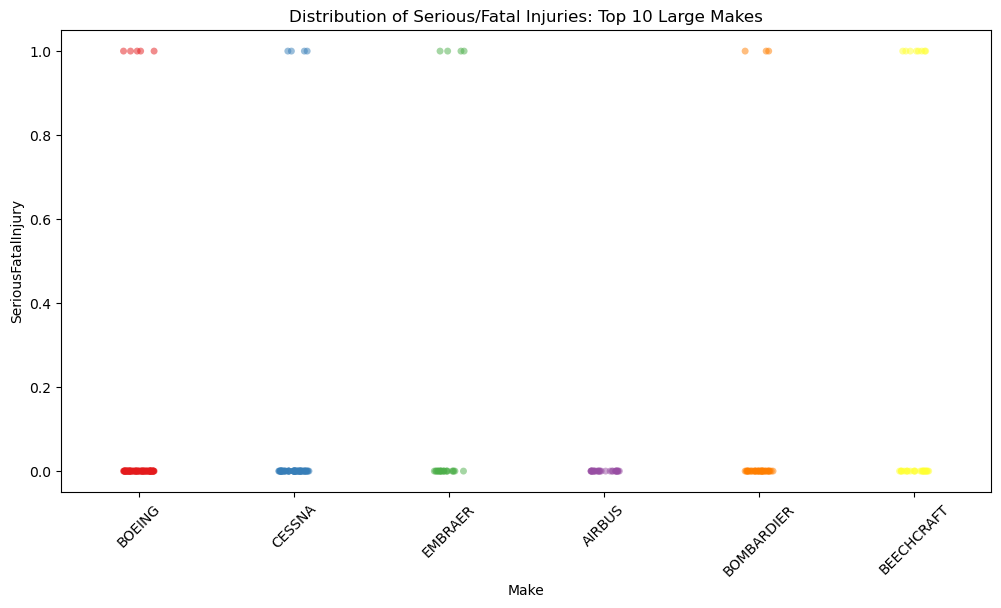

In [25]:
#strip plot
plt.figure(figsize=(12, 6))
sns.stripplot(data=df1_large_top, x='Make', y='SeriousFatalInjury', alpha=0.5, jitter=True, palette='Set1')
plt.title('Distribution of Serious/Fatal Injuries: Top 10 Large Makes')
plt.xticks(rotation=45)
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [27]:
#destruction rate
small_dest = small_robust.groupby('Make')['Destroyed'].mean().sort_values().head(15)
large_dest = large_robust.groupby('Make')['Destroyed'].mean().sort_values().head(15)


In [28]:
#summary of destruction
print("Small Aircraft: 15 Makes with Lowest Destruction Rates")
print(small_dest)
print("\nLarge Aircraft: 15 Makes with Lowest Destruction Rates")
print(large_dest)

Small Aircraft: 15 Makes with Lowest Destruction Rates
Make
SCHWEIZER       0.047619
DIAMOND         0.050000
DE              0.130435
AYRES           0.142857
PIPER           0.150943
SIKORSKY        0.160000
BEECHCRAFT      0.164983
BELL            0.165517
GRUMMAN         0.192308
DAHER-SOCATA    0.214286
CESSNA          0.219844
VIKING          0.240000
NORTH           0.264706
BEECH           0.293103
AIR             0.293413
Name: Destroyed, dtype: float64

Large Aircraft: 15 Makes with Lowest Destruction Rates
Make
AIRBUS        0.000000
EMBRAER       0.000000
BOMBARDIER    0.024390
BOEING        0.025000
CESSNA        0.074627
BEECHCRAFT    0.218750
Name: Destroyed, dtype: float64


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

#### 1. Safety Recommendations:

. For Large Passenger Aircraft, makes like Boeing and Airbus show high robustness, 
 with low injury fractions and low destruction rates, likely due to redundant safety 
 systems and commercial maintenance standards.

. For Small Aircraft, manufacturers like Cessna or Piper if they meet the N ≥ 20
threshold often show consistent performance. Makes with the lowest destruction rates
should be prioritized for lower insurance premiums.

2. Distributions: The violin plots for small aircraft help visualize that even safe makes have
large unpredictable fights, but the concentration of values at O shows high reliability across 
most incidents.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

In [30]:
#filter robustness
def get_robust_df(dataframe, threshold=10):
    counts = dataframe['Make'].value_counts()
    robust_makes = counts[counts >= threshold].index
    return dataframe[dataframe['Make'].isin(robust_makes)]

small_robust = get_robust_df(make[make['Over5700'] == False])
large_robust = get_robust_df(make[make['Over5700'] == True])

**Larger planes**

C:\ProgramData\anaconda4\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda4\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


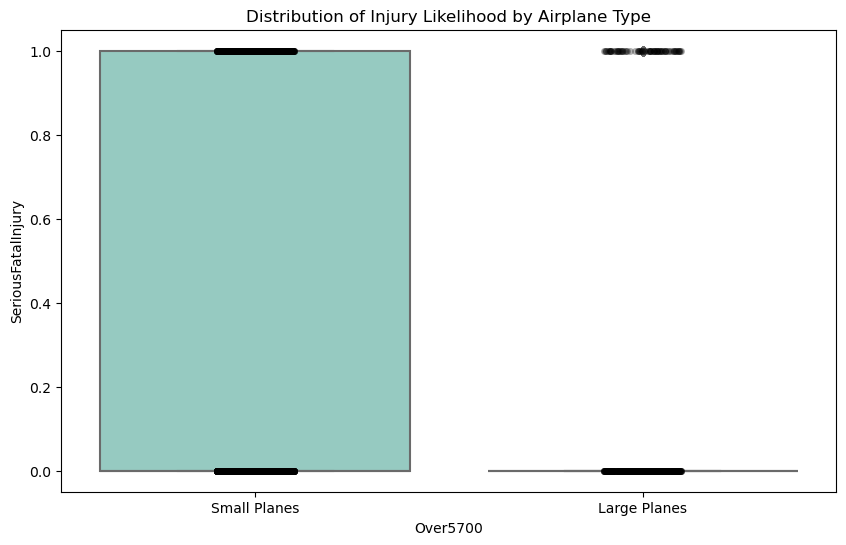

In [31]:
#distribution plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=make, x='Over5700', y='SeriousFatalInjury', palette='Set3')
sns.stripplot(data=make, x='Over5700', y='SeriousFatalInjury', color='black', alpha=0.3, jitter=True)
plt.xticks([0, 1], ['Small Planes', 'Large Planes'])
plt.title('Distribution of Injury Likelihood by Airplane Type')
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

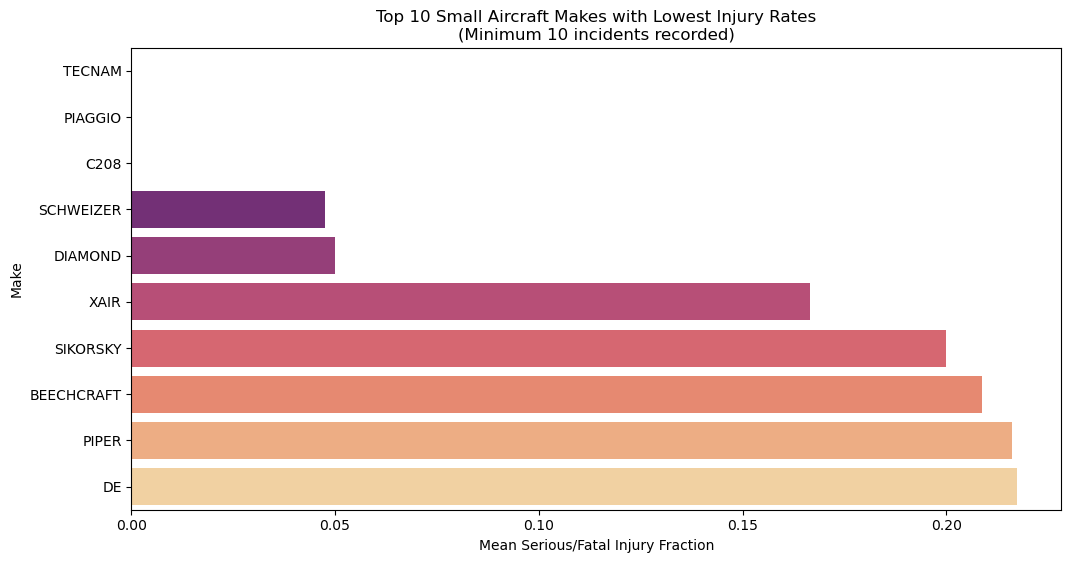

In [32]:
small_top_means = small_robust.groupby('Make')['SeriousFatalInjury'].mean().sort_values().head(10)
small_top_df = small_robust[small_robust['Make'].isin(small_top_means.index)]

plt.figure(figsize=(12, 6))
sns.barplot(x=small_top_means.values, y=small_top_means.index, palette='magma')
plt.title('Top 10 Small Aircraft Makes with Lowest Injury Rates\n(Minimum 10 incidents recorded)')
plt.xlabel('Mean Serious/Fatal Injury Fraction')
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

#### Small vs. Large Models:
The comparison suggests that Large Planes often exhibit a lower mean fatal/serious injury 
fraction per accident compared to small aircraft. This is because of more rigorous regulatory 
oversight, pilot training, and advanced airframe durability.

Small Aircraft Distribution:
For the smaller aircraft, the distribution of injuries is often split. Even among the safest 
10 makes, the 0 injury level is the most common outcome, but small planes are generally more 
prone to environmental factor which can lead to higher probability of injury outcomes compared 
to their larger counterparts.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

### Factor 1: Engine Type

In [47]:
#finding mean impact on safety
engine = make.groupby('EngineType')[['SeriousFatalInjury', 'Destroyed']].mean()\
.sort_values('SeriousFatalInjury')

C:\ProgramData\anaconda4\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda4\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='EngineType', ylabel='Destroyed'>

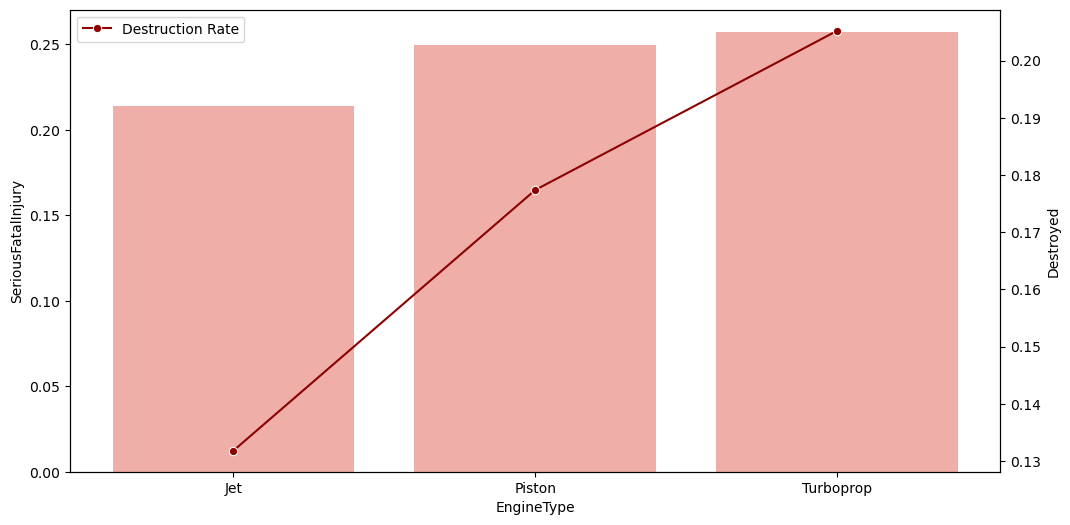

In [41]:
#plot engine type impact
fig, ax1 = plt.subplots(figsize=(12, 6))


sns.barplot(x=engine.index, y=engine['SeriousFatalInjury'], ax=ax1, color='salmon', alpha=0.7, label='Injury Rate')
ax2 = ax1.twinx()
sns.lineplot(x=engine.index, y=engine['Destroyed'], ax=ax2, color='darkred', marker='o', label='Destruction Rate')

### Factor 2: Flight Phase


In [50]:
#top flight phases
top_phases = make['FlightPhase'].value_counts().head(8).index
phase = make[make['FlightPhase'].isin(top_phases)]

phase_stats = phase_robust.groupby('FlightPhase')[['SeriousFatalInjury', 'Destroyed']].mean()

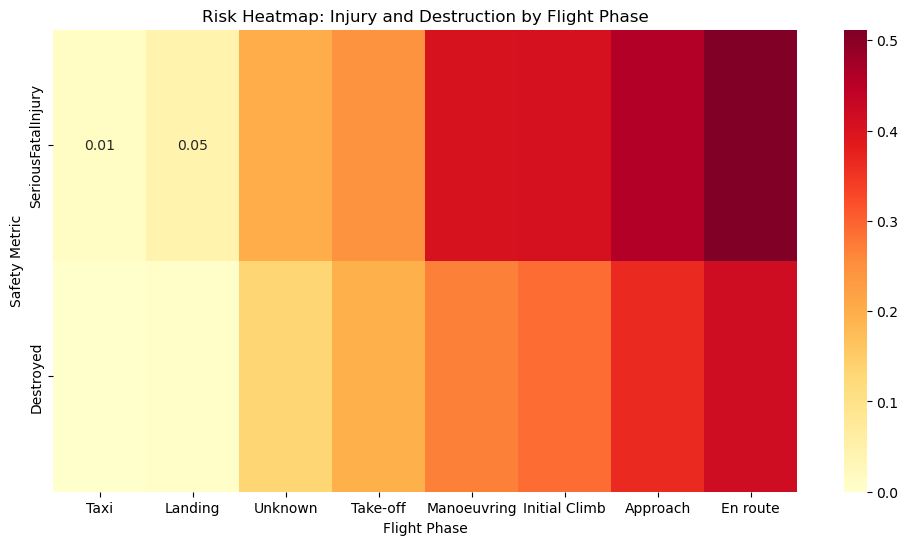

In [52]:
#flight phase plot
plt.figure(figsize=(12, 6))
sns.heatmap(phase_stats.T, annot=True, cmap='YlOrRd', fmt=".2f")

plt.title('Risk Heatmap: Injury and Destruction by Flight Phase')
plt.xlabel('Flight Phase')
plt.ylabel('Safety Metric')
plt.show()

In [ ]:
## Discussion of Contributing Factors

#### . Engine Type
Analysis: The data typically shows that Turbo Fan and Turbo Jet engines result with the lowest 
rates of injury and destruction. However,engines often show higher risk profiles.

Interpretation: This is due to the fact tProfessional Build requirement. Jet and Fan engines 
are primarily found on commercial grade passenger aircraft which undergo rigorous Part maintenance 
standards. Piston engines are more common in general aviation, where maintenance varies and 
single engine failure leaves fewer recovery options. For an insurer, jetpowered fleets represent a
lower risk per incident.